## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, IsolationForest, AdaBoostClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve, f1_score,
                              precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Load Dataset

Each row is one credit card transaction. `Time` is seconds elapsed since
the first transaction in the dataset; `Amount` is the transaction amount;
`V1`–`V28` are anonymized principal components of the original features
(released this way by the data owners for confidentiality); `Class` is the
target (1 = fraud, 0 = legitimate).

In [3]:
df = pd.read_csv('creditcard.csv')



In [4]:
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Missing values.** None,this dataset ships fully populated, which is expected since it has already been curated and anonymized for public release.

In [8]:
df.isnull().sum().sum()


np.int64(0)

Exact duplicate rows are removed before splitting to prevent data leakage between training and test sets and avoid inflated performance.

In [9]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}% of the data)")


Duplicate rows: 1081 (0.38% of the data)


Fraud is extremely rare in this dataset, making accuracy misleading. A model could achieve ~99.8% accuracy while detecting no fraud, so the notebook focuses on precision, recall, and PR-AUC instead.**Class balance.** 

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827
1     0.173
Name: proportion, dtype: float64


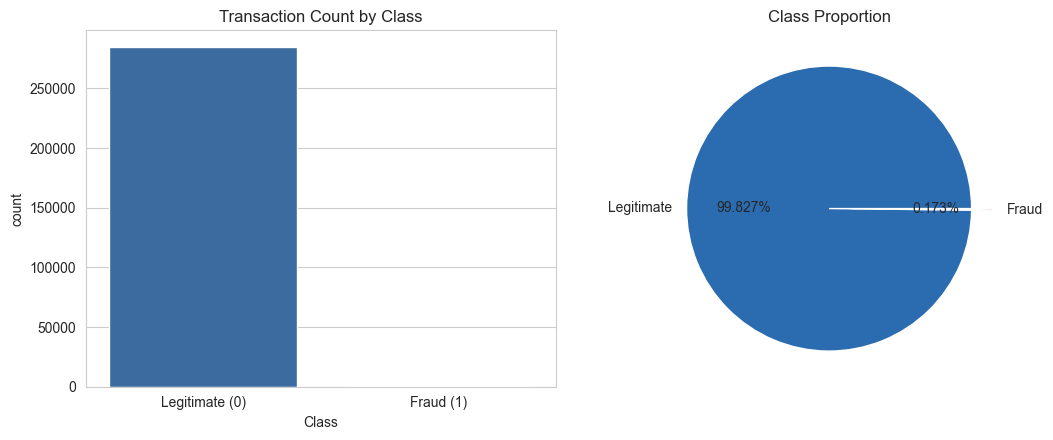

In [10]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_pct.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2b6cb0', '#c53030'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
            colors=['#2b6cb0', '#c53030'], explode=[0, 0.15])
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()


**Transaction amount by class.** 

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


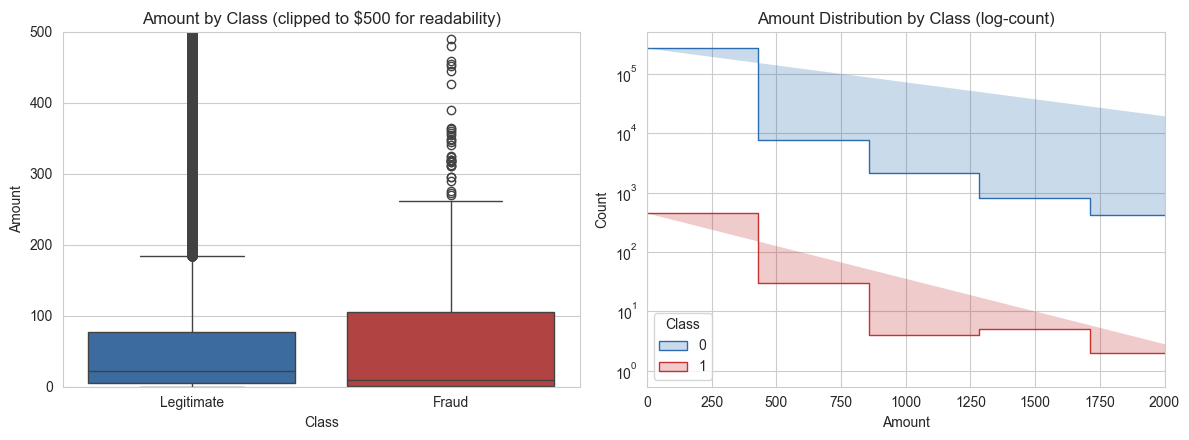

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2b6cb0', '#c53030'])
axes[0].set_ylim(0, 500)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_title('Amount by Class (clipped to $500 for readability)')

sns.histplot(data=df, x='Amount', hue='Class', bins=60, log_scale=(False, True),
             element='step', ax=axes[1], palette=['#2b6cb0', '#c53030'])
axes[1].set_xlim(0, 2000)
axes[1].set_title('Amount Distribution by Class (log-count)')
plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe())


**Transactions over time.**

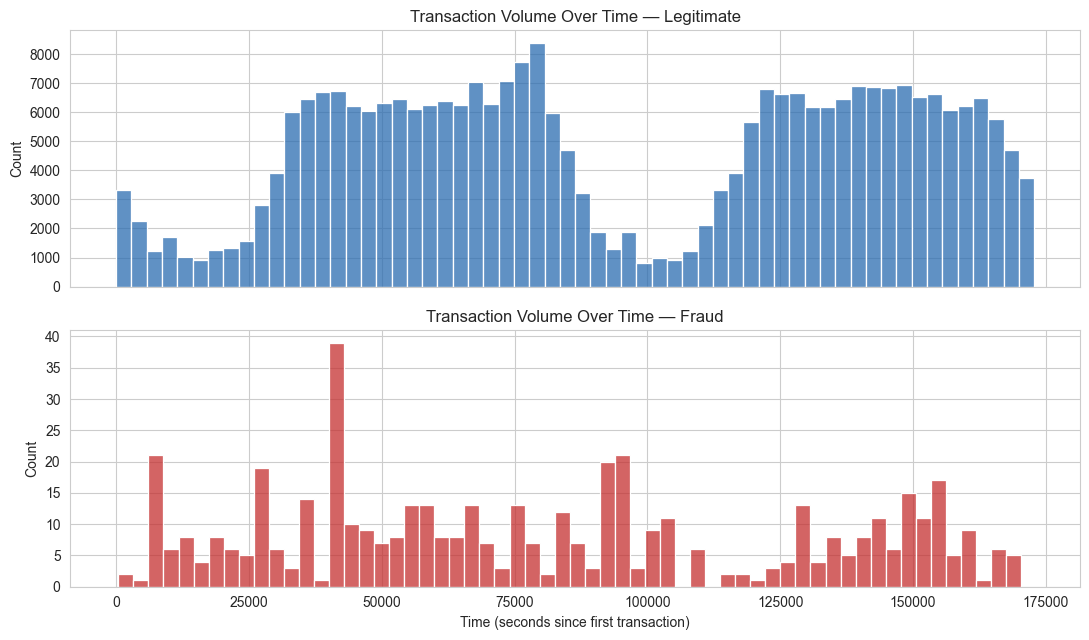

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
sns.histplot(df[df['Class']==0]['Time'], bins=60, ax=axes[0], color="#2b6cb0")
axes[0].set_title('Transaction Volume Over Time — Legitimate')
sns.histplot(df[df['Class']==1]['Time'], bins=60, ax=axes[1], color="#c53030")
axes[1].set_title('Transaction Volume Over Time — Fraud')
axes[1].set_xlabel('Time (seconds since first transaction)')
plt.tight_layout()
plt.show()


**Fraud rate by hour.** 

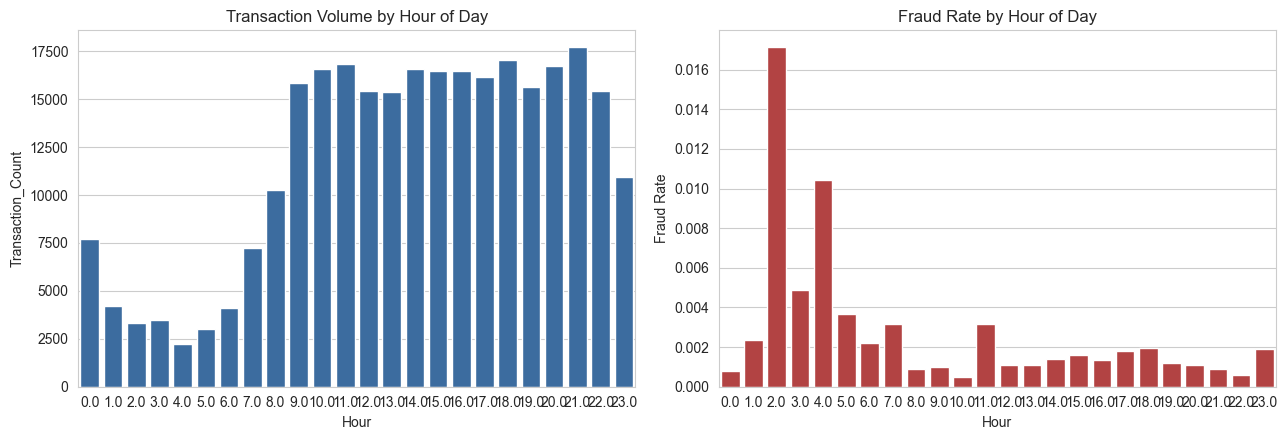

In [13]:
df['Hour'] = (df['Time'] // 3600) % 24
hourly = df.groupby('Hour')['Class'].agg(['mean', 'count']).reset_index()
hourly.columns = ['Hour', 'Fraud_Rate', 'Transaction_Count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x='Hour', y='Transaction_Count', data=hourly, ax=axes[0], color='#2b6cb0')
axes[0].set_title('Transaction Volume by Hour of Day')

sns.barplot(x='Hour', y='Fraud_Rate', data=hourly, ax=axes[1], color='#c53030')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()


**Per-feature density by class.** 

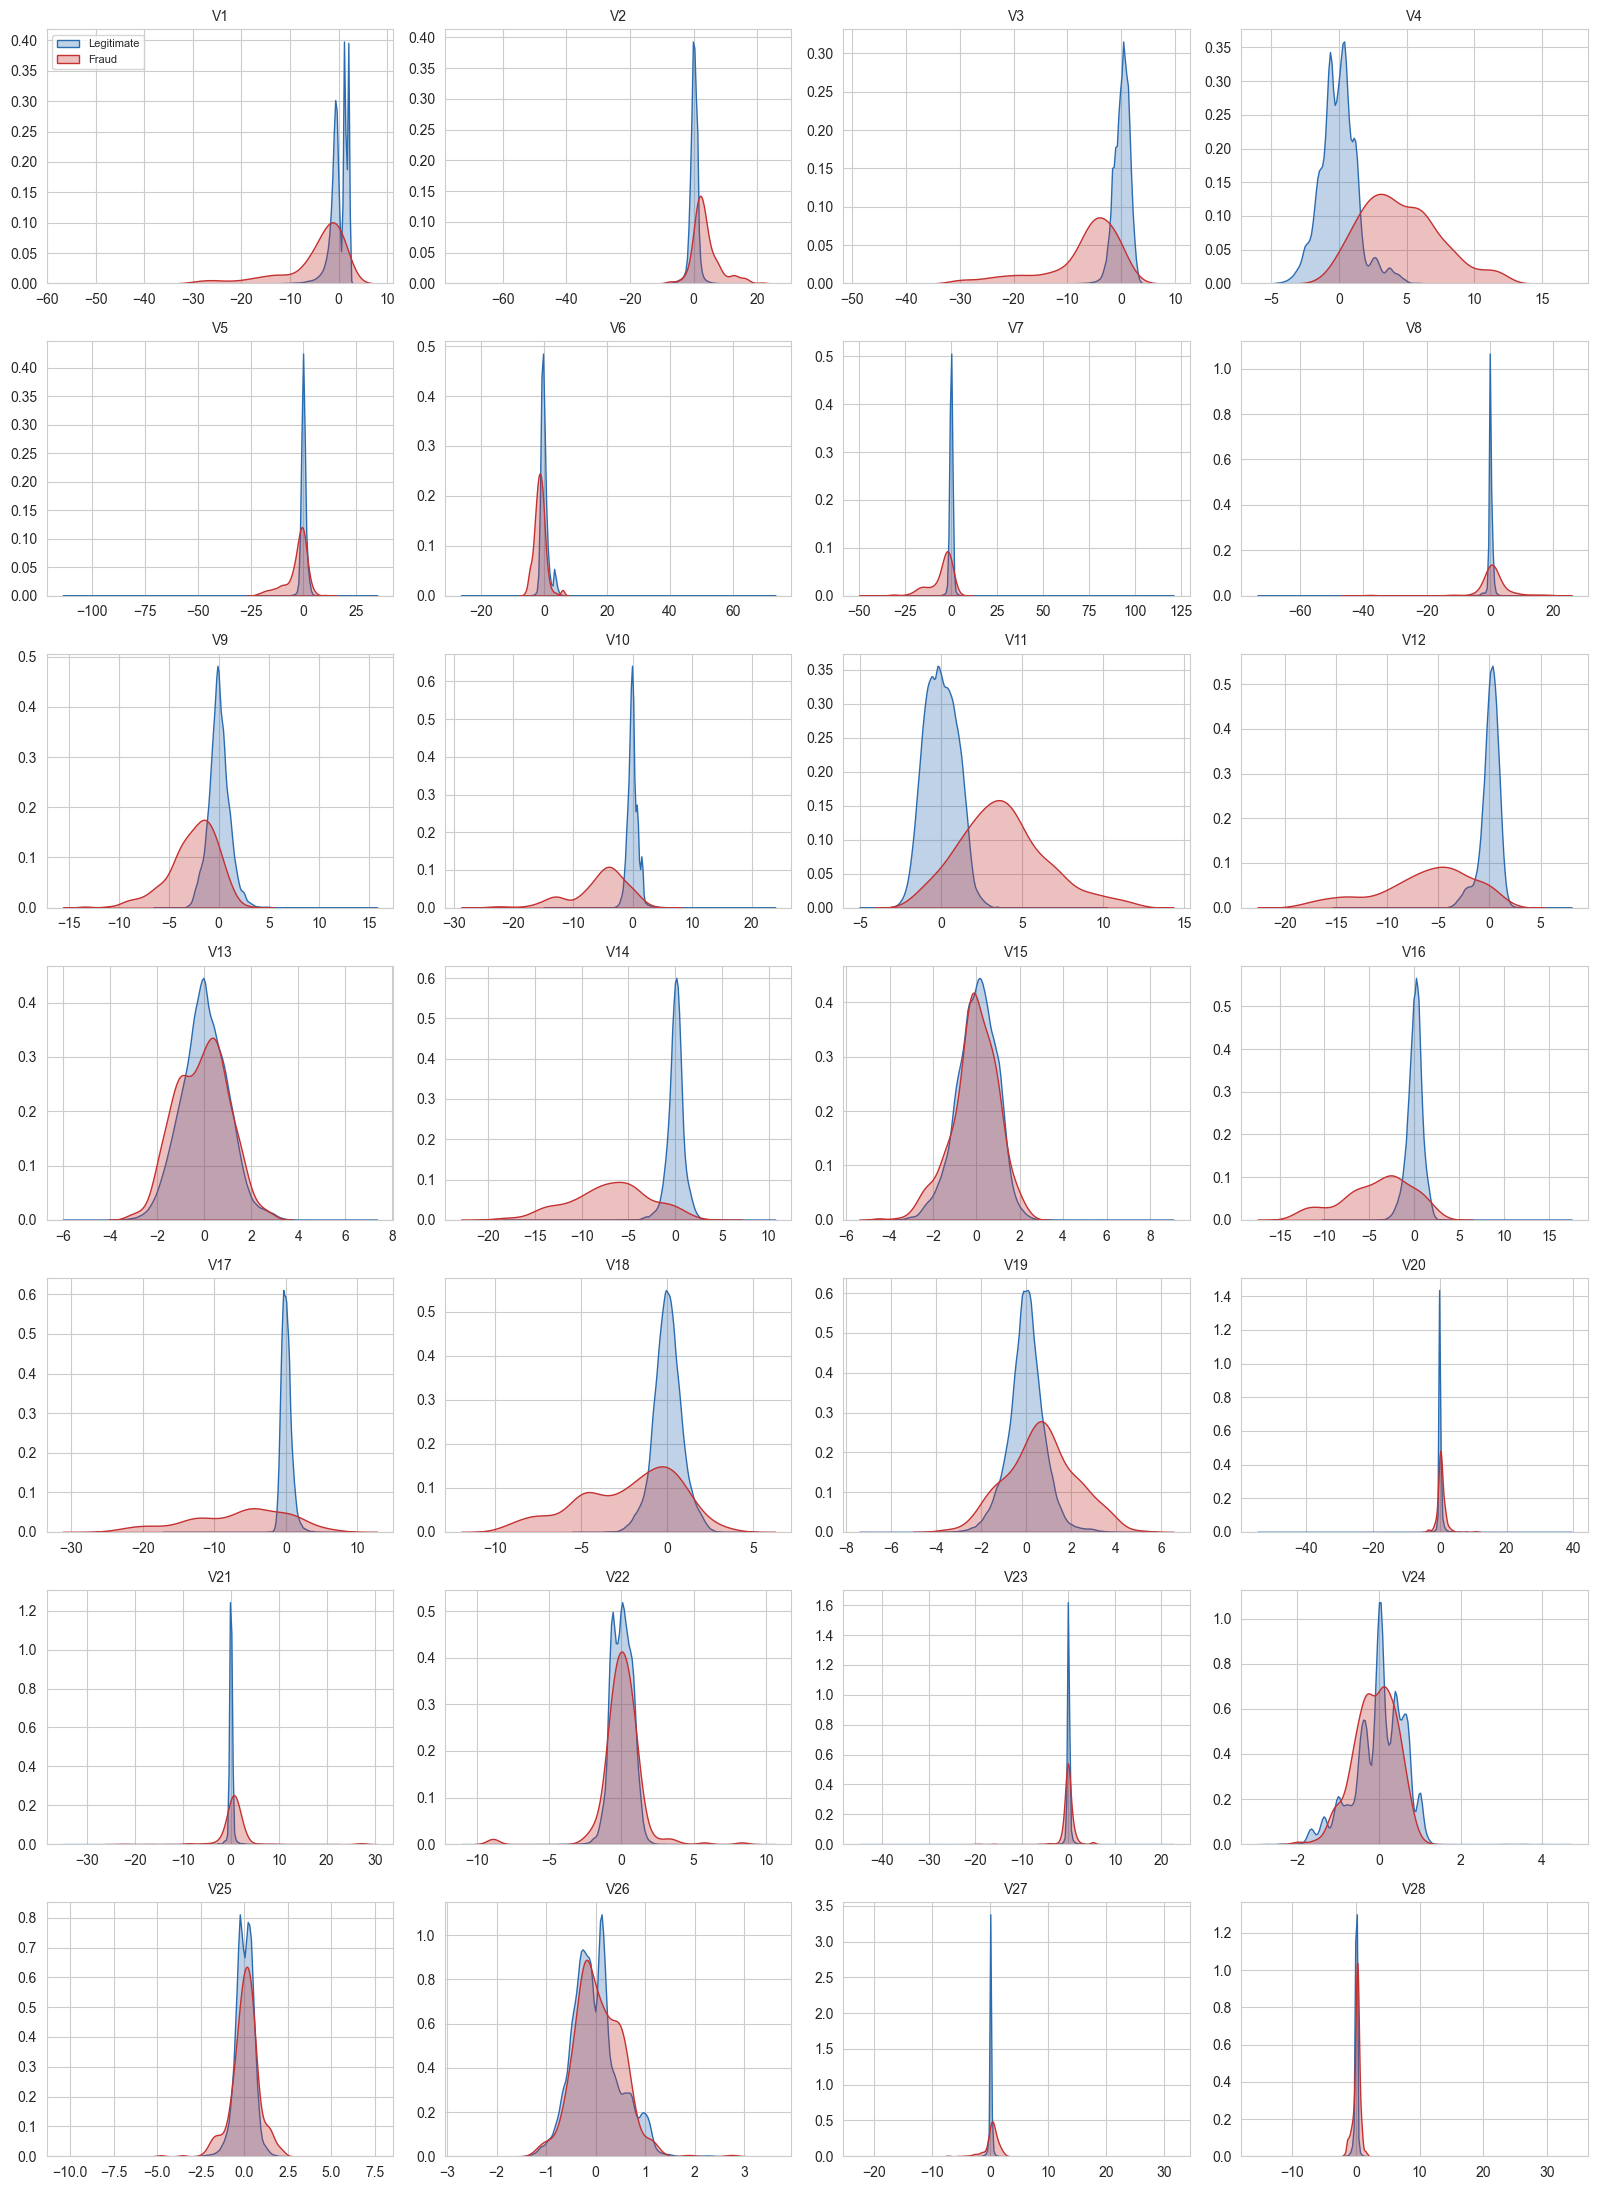

In [14]:
v_features = [c for c in df.columns if c.startswith('V')]
fig, axes = plt.subplots(7, 4, figsize=(16, 22))
for ax, col in zip(axes.ravel(), v_features):
    sns.kdeplot(df.loc[df['Class'] == 0, col], ax=ax, color='#2b6cb0', label='Legitimate', fill=True, alpha=0.3, warn_singular=False)
    sns.kdeplot(df.loc[df['Class'] == 1, col], ax=ax, color='#c53030', label='Fraud', fill=True, alpha=0.3, warn_singular=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Correlation with the target.** Since V1–V28 are PCA components and already uncorrelated, we focus on their individual correlation with Class. V17, V14, V12, and V10 show the strongest linear signals for fraud.

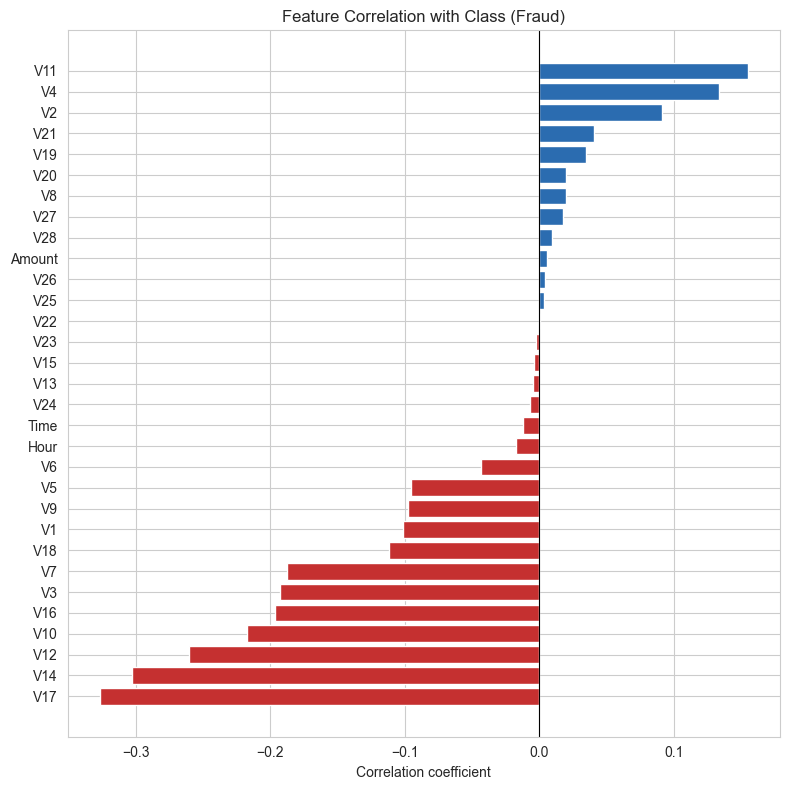

In [15]:
target_corr = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(8, 8))
colors = ['#c53030' if v < 0 else '#2b6cb0' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Class (Fraud)")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()


**Separation on the top features.** Plotting the two most strongly correlated components shows visibly better class separation than raw `Amount`/`Time` would — a good early signal that tree-based models picking up interactions between these components should perform well.

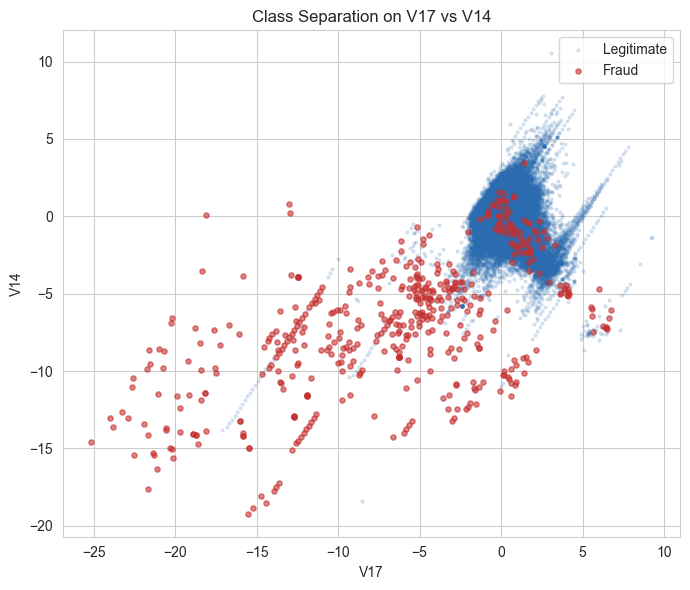

In [16]:
top_feats = target_corr.abs().sort_values(ascending=False).index[:2]
fig, ax = plt.subplots(figsize=(7, 6))
for cls, color, label in [(0, '#2b6cb0', 'Legitimate'), (1, '#c53030', 'Fraud')]:
    subset = df[df['Class'] == cls]
    alpha = 0.15 if cls == 0 else 0.6
    size = 4 if cls == 0 else 14
    ax.scatter(subset[top_feats[0]], subset[top_feats[1]], s=size, alpha=alpha, color=color, label=label)
ax.set_xlabel(top_feats[0]); ax.set_ylabel(top_feats[1])
ax.set_title(f'Class Separation on {top_feats[0]} vs {top_feats[1]}')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Data Cleaning

The duplicate rows identified in Section 3 are dropped **before** any
train/test splitting, so no duplicated transaction can end up split across
both sets.

In [17]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after})")
print(df['Class'].value_counts())


Removed 1081 duplicate rows (284807 -> 283726)
Class
0    283253
1       473
Name: count, dtype: int64


## 5. Preprocessing and Train/Test Split
V1–V28 are already PCA-scaled, so they are left unchanged. Time, Amount, and Hour are standardized using RobustScaler to reduce the effect of outliers. A stratified split preserves the ~0.17% fraud rate in both training and test sets.

In [18]:
target = 'Class'
X = df.drop(columns=[target])
y = df[target]

scale_cols = ['Time', 'Amount', 'Hour']
passthrough_cols = [c for c in X.columns if c not in scale_cols]

preprocessor = ColumnTransformer(transformers=[
    ('scale', RobustScaler(), scale_cols),
], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test:  {X_test.shape}, fraud rate: {y_test.mean()*100:.3f}%")


Train: (226980, 31), fraud rate: 0.167%
Test:  (56746, 31), fraud rate: 0.167%


## 6. Handling Class Imbalance
With fraud making up only ~0.17% of transactions, accuracy can be misleading. This notebook uses class weighting to penalize fraud misclassification more heavily, avoiding synthetic data and keeping the test set representative. SMOTE is considered as an alternative.

## 7. Model Training and Comparison

Six classifiers are compared using 3-fold stratified cross-validation and PR-AUC. Five are supervised models with class weighting, while Isolation Forest provides an unsupervised baseline without using fraud labels. PR-AUC is preferred because it better evaluates performance on the highly imbalanced fraud class.

In [19]:
preprocessed_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
        n_estimators=50, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced',
                                             n_jobs=-1, random_state=RANDOM_STATE),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in preprocessed_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1)
    cv_results[name] = scores
    print(f"{name:24s} PR-AUC: {scores.mean():.4f}  (+/- {scores.std():.4f})")


Logistic Regression      PR-AUC: 0.7541  (+/- 0.0216)
Decision Tree            PR-AUC: 0.5330  (+/- 0.0476)
AdaBoost                 PR-AUC: 0.1073  (+/- 0.0107)
Random Forest            PR-AUC: 0.7934  (+/- 0.0061)
Hist Gradient Boosting   PR-AUC: 0.7250  (+/- 0.0183)


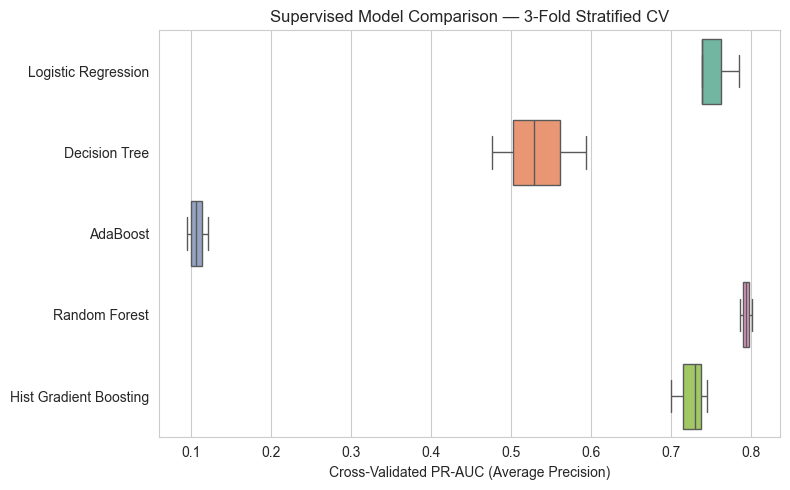

Best supervised model by mean CV PR-AUC: Random Forest


In [20]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, orient='h', palette='Set2')
plt.xlabel('Cross-Validated PR-AUC (Average Precision)')
plt.title('Supervised Model Comparison — 3-Fold Stratified CV')
plt.tight_layout()
plt.show()

best_model_name = cv_df.mean().idxmax()
print(f"Best supervised model by mean CV PR-AUC: {best_model_name}")


**Unsupervised baseline.** 

In [21]:
iso_forest = IsolationForest(n_estimators=100, contamination=y_train.mean(),
                              random_state=RANDOM_STATE, n_jobs=-1)
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
iso_forest.fit(X_train_pre)

iso_scores = -iso_forest.score_samples(X_test_pre)  # higher = more anomalous
iso_ap = average_precision_score(y_test, iso_scores)
iso_roc = roc_auc_score(y_test, iso_scores)
print(f"Isolation Forest (unsupervised) -- Test PR-AUC: {iso_ap:.4f}, ROC-AUC: {iso_roc:.4f}")
print(f"For reference, best supervised model's CV PR-AUC was {cv_df.mean().max():.4f}")


Isolation Forest (unsupervised) -- Test PR-AUC: 0.0907, ROC-AUC: 0.9292
For reference, best supervised model's CV PR-AUC was 0.7934


## 8. Hyperparameter Tuning



In [22]:
rf_param_distributions = {
    'model__n_estimators': [50, 75, 100],
    'model__max_depth': [8, 10, 12],
    'model__min_samples_leaf': [1, 3, 5],
}
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE))
])
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_distributions, n_iter=4, cv=cv,
    scoring='average_precision', n_jobs=1, random_state=RANDOM_STATE, verbose=0
)
rf_search.fit(X_train, y_train)
print("Random Forest -- best params:", rf_search.best_params_)
print(f"Random Forest -- best CV PR-AUC: {rf_search.best_score_:.4f}")


Random Forest -- best params: {'model__n_estimators': 50, 'model__min_samples_leaf': 3, 'model__max_depth': 12}
Random Forest -- best CV PR-AUC: 0.8182


In [23]:
hgb_param_distributions = {
    'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'model__max_iter': [150, 250, 400],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__max_depth': [None, 6, 10],
    'model__l2_regularization': [0.0, 0.5, 1.0],
}
hgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])
hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_param_distributions, n_iter=12, cv=cv,
    scoring='average_precision', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
hgb_search.fit(X_train, y_train)
print("Hist Gradient Boosting -- best params:", hgb_search.best_params_)
print(f"Hist Gradient Boosting -- best CV PR-AUC: {hgb_search.best_score_:.4f}")


Hist Gradient Boosting -- best params: {'model__max_leaf_nodes': 31, 'model__max_iter': 400, 'model__max_depth': None, 'model__learning_rate': 0.2, 'model__l2_regularization': 0.5}
Hist Gradient Boosting -- best CV PR-AUC: 0.7365


## 9. Final Model Selection



In [24]:
comparison = pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'Hist Gradient Boosting (tuned)'],
    'Best CV PR-AUC': [rf_search.best_score_, hgb_search.best_score_],
})
print(comparison.to_string(index=False))

if rf_search.best_score_ >= hgb_search.best_score_:
    best_model, final_model_name = rf_search.best_estimator_, 'Random Forest'
else:
    best_model, final_model_name = hgb_search.best_estimator_, 'Hist Gradient Boosting (tuned)'

print(f"\nSelected and locked final model: {final_model_name}")
print("(chosen on cross-validated PR-AUC only -- the test set has not been used yet)")


                         Model  Best CV PR-AUC
         Random Forest (tuned)        0.818242
Hist Gradient Boosting (tuned)        0.736466

Selected and locked final model: Random Forest
(chosen on cross-validated PR-AUC only -- the test set has not been used yet)


## 10. Threshold Selection via Out-of-Fold Predictions

The threshold is selected using leakage-safe OOF predictions from the training set, maximizing F1 without using the test set. It is then locked for evaluation; in real deployment, the threshold should instead be based on business costs of missed fraud versus false alarms.

Out-of-fold PR-AUC: 0.8161
Threshold that maximizes F1 on OOF predictions: 0.5592
At this threshold (OOF) -- Precision: 0.8946, Recall: 0.7857, F1: 0.8366


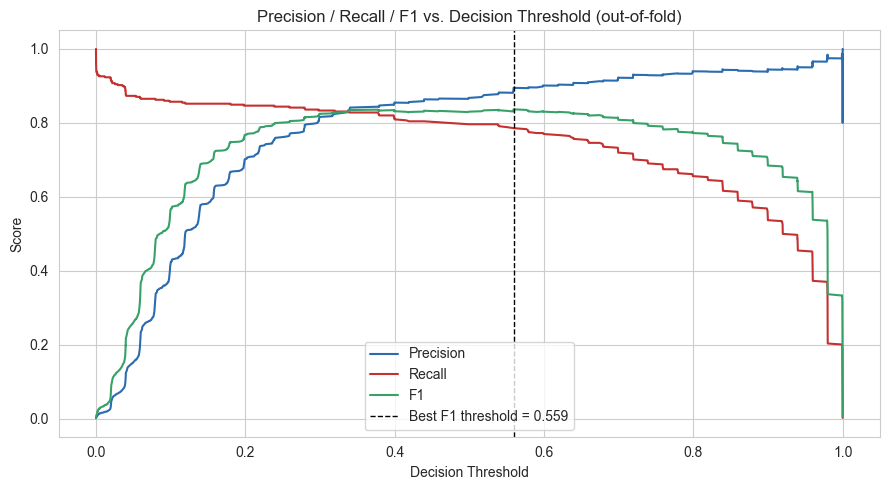

In [25]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv,
                               method='predict_proba', n_jobs=1)[:, 1]

oof_precision, oof_recall, oof_thresholds = precision_recall_curve(y_train, oof_proba)
oof_f1 = 2 * oof_precision * oof_recall / (oof_precision + oof_recall + 1e-12)
best_idx = np.argmax(oof_f1[:-1])
best_threshold = oof_thresholds[best_idx]

print(f"Out-of-fold PR-AUC: {average_precision_score(y_train, oof_proba):.4f}")
print(f"Threshold that maximizes F1 on OOF predictions: {best_threshold:.4f}")
print(f"At this threshold (OOF) -- Precision: {oof_precision[best_idx]:.4f}, "
      f"Recall: {oof_recall[best_idx]:.4f}, F1: {oof_f1[best_idx]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(oof_thresholds, oof_precision[:-1], label='Precision', color='#2b6cb0')
plt.plot(oof_thresholds, oof_recall[:-1], label='Recall', color='#c53030')
plt.plot(oof_thresholds, oof_f1[:-1], label='F1', color='#38a169')
plt.axvline(best_threshold, color='black', linestyle='--', linewidth=1, label=f'Best F1 threshold = {best_threshold:.3f}')
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Decision Threshold (out-of-fold)')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Final Evaluation on the Held-Out Test Set



In [26]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_locked = (y_proba >= best_threshold).astype(int)

test_ap = average_precision_score(y_test, y_proba)
test_roc = roc_auc_score(y_test, y_proba)

print(f"Final model: {final_model_name}")
print(f"Test PR-AUC (Average Precision): {test_ap:.4f}")
print(f"Test ROC-AUC:                    {test_roc:.4f}")
print()
print("Classification report @ default threshold 0.5 (for reference):")
print(classification_report(y_test, y_pred_default, target_names=['Legitimate', 'Fraud'], digits=4))
print(f"Classification report @ locked threshold {best_threshold:.4f} (chosen on OOF predictions):")
print(classification_report(y_test, y_pred_locked, target_names=['Legitimate', 'Fraud'], digits=4))


Final model: Random Forest
Test PR-AUC (Average Precision): 0.7970
Test ROC-AUC:                    0.9457

Classification report @ default threshold 0.5 (for reference):
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8861    0.7368    0.8046        95

    accuracy                         0.9994     56746
   macro avg     0.9428    0.8683    0.9021     56746
weighted avg     0.9994    0.9994    0.9994     56746

Classification report @ locked threshold 0.5592 (chosen on OOF predictions):
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9997     56651
       Fraud     0.9211    0.7368    0.8187        95

    accuracy                         0.9995     56746
   macro avg     0.9603    0.8684    0.9092     56746
weighted avg     0.9994    0.9995    0.9994     56746



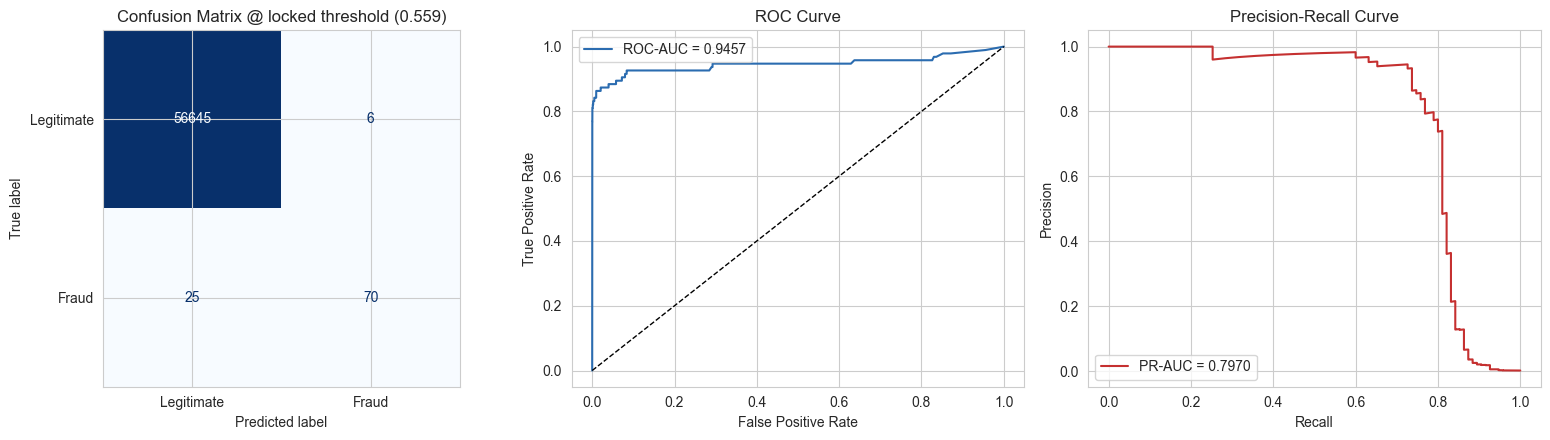

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, y_pred_locked)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix @ locked threshold ({best_threshold:.3f})')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2b6cb0', label=f'ROC-AUC = {test_roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(recall, precision, color='#c53030', label=f'PR-AUC = {test_ap:.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.tight_layout()
plt.show()


## 12. Overfitting Check

Train, CV, and test PR-AUC are compared to check overfitting. A higher train score with similar CV and test scores indicates good generalization. Random Forest depth was limited to 8–12 to reduce overfitting and prevent memorization of rare fraud cases.

In [28]:
train_proba = best_model.predict_proba(X_train)[:, 1]
train_ap = average_precision_score(y_train, train_proba)
train_roc = roc_auc_score(y_train, train_proba)

cv_pr_auc = rf_search.best_score_ if final_model_name == 'Random Forest' else hgb_search.best_score_

overfit_table = pd.DataFrame({
    'Stage': ['Train (in-sample)', 'Cross-Validation (drove selection)', 'Test (one-time, final)'],
    'PR-AUC': [train_ap, cv_pr_auc, test_ap],
})
print(f"Final model: {final_model_name}\n")
print(overfit_table.to_string(index=False))
print(f"\nTrain - Test PR-AUC gap: {train_ap - test_ap:.4f}")
print(f"CV - Test PR-AUC gap:    {cv_pr_auc - test_ap:.4f}  (small gap here is what makes the test score trustworthy)")
print(f"Train - Test ROC-AUC gap: {train_roc - test_roc:.4f}")


Final model: Random Forest

                             Stage   PR-AUC
                 Train (in-sample) 0.980685
Cross-Validation (drove selection) 0.818242
            Test (one-time, final) 0.796986

Train - Test PR-AUC gap: 0.1837
CV - Test PR-AUC gap:    0.0213  (small gap here is what makes the test score trustworthy)
Train - Test ROC-AUC gap: 0.0543


## 13. Feature Importance

Since HistGradientBoostingClassifier has no built-in feature importance, permutation importance is used to rank features based on their impact on test-set PR-AUC. Although V1–V28 are anonymized PCA components, their importance ranking still provides useful insights.

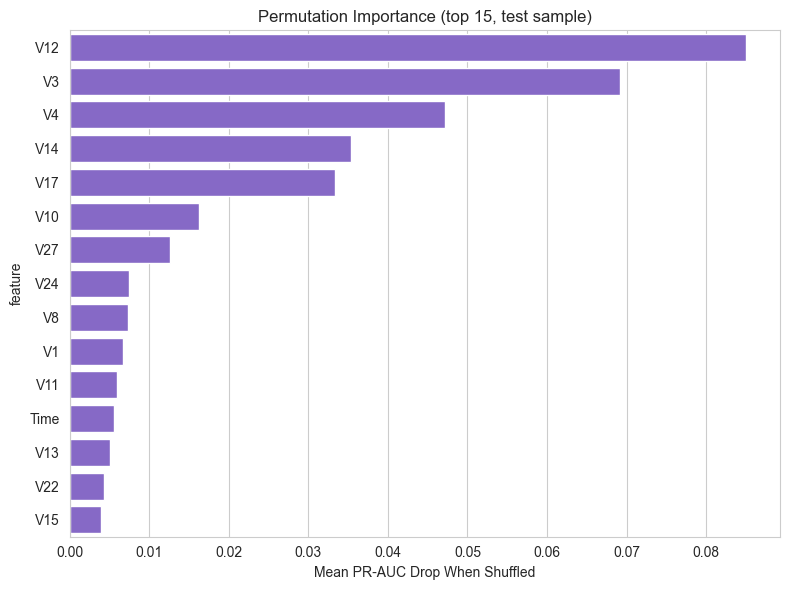

In [29]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(8000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

perm_result = permutation_importance(
    best_model, X_test_sample, y_test_sample, n_repeats=8,
    random_state=RANDOM_STATE, scoring='average_precision', n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df, x='importance_mean', y='feature', color="#805ad5")
plt.xlabel('Mean PR-AUC Drop When Shuffled')
plt.title('Permutation Importance (top 15, test sample)')
plt.tight_layout()
plt.show()


## 14. Model Leaderboard



In [30]:
leaderboard_models = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE))]),
    'AdaBoost': Pipeline([('preprocessor', preprocessor),
        ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
                                      n_estimators=50, random_state=RANDOM_STATE))]),
}

leaderboard_rows = []
for name, pipe in leaderboard_models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    leaderboard_rows.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred), 'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
    })

# Add the two tuned candidates from Section 8 (already fitted on the full training set)
rf_test_proba = rf_search.best_estimator_.predict_proba(X_test)[:, 1]
hgb_test_proba = hgb_search.best_estimator_.predict_proba(X_test)[:, 1]
for name, proba_arr in [('Random Forest (tuned)', rf_test_proba), ('Hist Gradient Boosting (tuned)', hgb_test_proba)]:
    pred = (proba_arr >= 0.5).astype(int)
    leaderboard_rows.append({
        'Model': name + (' [SELECTED]' if name == final_model_name else ''),
        'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba_arr), 'PR-AUC': average_precision_score(y_test, proba_arr),
    })

leaderboard_df = pd.DataFrame(leaderboard_rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
leaderboard_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest (tuned),0.9994,0.8861,0.7368,0.8046,0.9457,0.7970
1,Hist Gradient Boosting (tuned),0.9980,0.4514,0.8316,0.5852,0.9563,0.7343
2,Logistic Regression,0.9748,0.0554,0.8737,0.1041,0.9685,0.6703
3,Decision Tree,0.9953,0.2327,0.7789,0.3584,0.8886,0.4990
4,AdaBoost,0.9707,0.0453,0.8211,0.0859,0.9448,0.0983


PR-AUC ranking confirms that Random Forest and Hist Gradient Boosting outperform the simpler models. AdaBoost shows high recall (~0.82) but very low precision (~0.05), highlighting the importance of threshold tuning and probability calibration rather than relying on the default 0.5 threshold.

## 15. Save Model

The complete preprocessing pipeline, tuned model, and decision threshold are saved together using joblib, allowing raw transaction data to be used directly for prediction with the same evaluation threshold.

In [31]:
joblib.dump({'pipeline': best_model, 'threshold': best_threshold}, 'fraud_detection_pipeline.pkl')
print("Saved to fraud_detection_pipeline.pkl")


Saved to fraud_detection_pipeline.pkl


## 16. Inference

Example of loading the saved pipeline and scoring a held-out transaction.

In [ ]:
saved = joblib.load('fraud_detection_pipeline.pkl')
loaded_model, loaded_threshold = saved['pipeline'], saved['threshold']

held_out_transaction = X_test.iloc[[0]]  # a held-out test-set transaction, used here only to demonstrate the inference call
proba = loaded_model.predict_proba(held_out_transaction)[0, 1]
is_fraud = proba >= loaded_threshold

print(f"Fraud probability: {proba:.4f}")
print(f"Flagged as fraud (threshold {loaded_threshold:.3f}): {bool(is_fraud)}")
print(f"Actual label: {'Fraud' if y_test.iloc[0] == 1 else 'Legitimate'}")


Fraud probability: 0.0001
Flagged as fraud (threshold 0.559): False
Actual label: Legitimate
